In [1]:
using Plots

In [18]:
mutable struct SMAC
    # grid parameters
    X_grid::Int
    Y_grid::Int
    size_X::Float64
    size_Y::Float64
    dx::Float64
    dy::Float64

    # column parameters
    col_x1
    col_x2
    col_y1
    col_y2
    is_solve_vx
    is_solve_vy
    is_solve_p

    # time parameters
    time::Float64
    dt::Float64
    step_counter::Int
    endtime::Float64

    # physical parameter
    viscosity_coef::Float64

    # hyper parameters
    cell_reynolds::Float64
    sor_acceleration_rate::Float64
    sor_convergence_criterion::Float64
    cfl::Float64
    scheme

    # value of cells
    velocity_x
    velocity_y
    velocity_x_new
    velocity_y_new
    pressure
    pressure_correction

    # coefficients of discrete equation
    _ae
    _aw
    _an
    _as
    _ap
    _b

    # boundary condition
    velocity_of_inflow::Float64

    # results
    time_strouhal
    strouhal

    function SMAC(cell_reynolds, scheme; X_grid=250, Y_grid=50, size_X=25.0, size_Y=5.0, velocity_of_inflow=1.0, sor_acceleration_rate=1.85, sor_convergence_criterion=0.000001, endtime=120.0)
        dx = size_X / X_grid
        dy = size_Y / Y_grid
        viscosity_coef = 1.0 / cell_reynolds
        step_counter = 0
        time = 0.0

        if scheme == "center"
            cfl = 0.1
        elseif scheme == "upwind"
            cfl = 0.4
        elseif scheme == "hybrid"
            cfl = 0.4
        else
            error("invalid scheme: try again")
        end

        position_x = 4.0
        col_size = 1.0
        col_x1 = Int(round(position_x / dx)) + 1
        col_x2 = Int(round((position_x + col_size) / dx)) + 1
        col_y1 = Int(round((size_Y / 2.0 - col_size / 2.0) / dy)) + 1
        col_y2 = Int(round((size_Y / 2.0 + col_size / 2.0) / dy)) + 1
        is_solve_vx = falses(X_grid+2, Y_grid+2)
        is_solve_vy = falses(X_grid+2, Y_grid+2)
        is_solve_p = falses(X_grid+2, Y_grid+2)
        for i = 2 : X_grid, j = 2 : Y_grid + 1
            is_solve_vx[i, j] = true
        end
        for i = col_x1 : col_x2, j = col_y1 + 1 : col_y2
            is_solve_vx[i, j] = false
        end
        for i = 2 : X_grid + 1, j = 2 : Y_grid
            is_solve_vy[i, j] = true
        end
        for i = col_x1 + 1 : col_x2, j = col_y1 : col_y2
            is_solve_vy[i, j] = false
        end
        for i = 2 : X_grid + 1, j = 2 : Y_grid + 1
            is_solve_p[i, j] = true
        end
        for i = col_x1 + 1 : col_x2, j = col_y1 + 1 : col_y2
            is_solve_p[i, j] = false
        end

        velocity_x = zeros(X_grid+2, Y_grid+2)
        velocity_y = zeros(X_grid+2, Y_grid+2)
        pressure = zeros(X_grid+2, Y_grid+2)
        pressure_correction = zeros(X_grid+2, Y_grid+2)
        for j = 2 : Y_grid + 1
            velocity_x[1, j] = velocity_of_inflow
        end
        velocity_x_new = copy(velocity_x)
        velocity_y_new = copy(velocity_y)
        for i = 2 : X_grid, j = 2 : Y_grid + 1
            if is_solve_vx[i, j]
                if (col_x1 <= i <= col_x2)
                    velocity_x[i, j] = velocity_of_inflow * size_Y / (size_Y - col_size)
                else
                    velocity_x[i, j] = velocity_of_inflow
                end
            end
        end

        _ae = zeros(X_grid+2, Y_grid+2)
        _aw = zeros(X_grid+2, Y_grid+2)
        _an = zeros(X_grid+2, Y_grid+2)
        _as = zeros(X_grid+2, Y_grid+2)
        _ap = zeros(X_grid+2, Y_grid+2)
        _b = zeros(X_grid+2, Y_grid+2)
        inv_dx = 1.0 / dx ^ 2
        inv_dy = 1.0 / dy ^ 2
        for i = 2 : X_grid + 1, j = 2 : Y_grid + 1
            _ae[i, j] = inv_dx
            _aw[i, j] = inv_dx
            _an[i, j] = inv_dy
            _as[i, j] = inv_dy
            _ap[i, j] = 2.0 * (inv_dx + inv_dy)

            if j == 2
                _ap[i, j] -= _as[i, j]
                _as[i, j] = 0.0
            end
            if j == Y_grid + 1
                _ap[i, j] -= _an[i, j]
                _an[i, j] = 0.0
            end
            if i == 2
                _ap[i, j] -= _aw[i, j]
                _aw[i, j] = 0.0
            end
            if i == X_grid + 1
                _ap[i, j] -= _ae[i, j]
                _ae[i, j] = 0.0
            end
        end
        for i = col_x1 + 1 : col_x2
            _ap[i, col_y1] -= _an[i, col_y1]
            _an[i, col_y1] = 0.0
            _ap[i, col_y2 + 1] -= _as[i, col_y2 + 1]
            _as[i, col_y2 + 1] = 0.0
        end
        for j = col_y1 + 1 : col_y2
            _ap[col_x1, j] -= _ae[col_x1, j]
            _ae[col_x1, j] = 0.0
            _ap[col_x2 + 1, j] -= _aw[col_x2 + 1, j]
            _aw[col_x2 + 1, j] = 0.0
        end

        dt = cfl / (velocity_of_inflow / dx + 2.0 * viscosity_coef * (inv_dx + inv_dy))
        X_grid += 1
        Y_grid += 1
        time_strouhal = []
        strouhal = []

        new(X_grid, Y_grid, size_X, size_Y, dx, dy,
            col_x1, col_x2, col_y1, col_y2, is_solve_vx, is_solve_vy, is_solve_p, time, dt, step_counter, endtime, viscosity_coef,
            cell_reynolds, sor_acceleration_rate, sor_convergence_criterion, cfl, scheme,
            velocity_x, velocity_y, velocity_x_new, velocity_y_new, pressure, pressure_correction,
            _ae, _aw, _an, _as, _ap, _b, velocity_of_inflow, time_strouhal, strouhal)
    end
end

function show_settings(smac)
    println("<settings>")
    println("X_grid = $(smac.X_grid - 1), Y_grid = $(smac.Y_grid - 1)\n(X_size, Y_size) = ($(smac.size_X), $(smac.size_Y))\ndx = $(smac.dx), dy = $(smac.dy)")
    println("viscosity_coef = $(smac.viscosity_coef), reynolds number = $(smac.cell_reynolds)\nsor_acceleration_rate = $(smac.sor_acceleration_rate), sor_convergence_criterion = $(smac.sor_convergence_criterion)")
    println("scheme = $(smac.scheme), CFL number = $(smac.cfl), dt = $(smac.dt)")
    println("velocity_of_inflow = $(smac.velocity_of_inflow)\n")
end

function show_progress(smac)
    if smac.step_counter % 100 == 0
        println("step = $(smac.step_counter): time = $(smac.time) / $(smac.endtime)")
    end
end

function solve!(smac)
    show_settings(smac)
    while smac.time < smac.endtime
        smac.step_counter += 1
        smac.time += smac.dt
        boundary_condition!(smac)
        velocity_x_update!(smac)
        velocity_y_update!(smac)
        correction!(smac)
        show_progress(smac)
        strouhal!(smac)
    end
    boundary_shaping!(smac)
end

function boundary_condition!(smac)
    for i = 2 : smac.X_grid
        smac.velocity_x[i, 1] = smac.velocity_x[i, 2]
        smac.velocity_x[i, smac.Y_grid + 1] = smac.velocity_x[i, smac.Y_grid]
    end
    for j = 2 : smac.Y_grid
        smac.velocity_y[1, j] = -smac.velocity_y[2, j]
        smac.pressure[smac.X_grid + 1, j] = -smac.pressure[smac.X_grid, j]
    end
end

function velocity_x_update!(smac)
    flux_e = Array{Float64}(undef, smac.X_grid+1, smac.Y_grid+1)
    flux_n = Array{Float64}(undef, smac.X_grid+1, smac.Y_grid+1)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid
        vxe = (smac.velocity_x[i, j] + smac.velocity_x[i+1, j]) * 0.5
        vyn = (smac.velocity_y[i, j] + smac.velocity_y[i+1, j]) * 0.5

        if smac.scheme == "center"
            flux_e[i, j] = vxe * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) * 0.5 - smac.viscosity_coef / smac.dx * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            flux_n[i, j] = vyn * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) * 0.5 - smac.viscosity_coef / smac.dy * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        elseif smac.scheme == "upwind"
            flux_e[i, j] = vxe * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) * 0.5 - (smac.viscosity_coef / smac.dx + 0.5 * abs(vxe)) * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            flux_n[i, j] = vyn * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) * 0.5 - (smac.viscosity_coef / smac.dy + 0.5 * abs(vyn)) * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        elseif smac.scheme == "hybrid"
            flux_e[i, j] = vxe * (smac.velocity_x[i+1, j] + smac.velocity_x[i, j]) * 0.5 - max(smac.viscosity_coef / smac.dx, 0.5 * abs(vxe)) * (smac.velocity_x[i+1, j] - smac.velocity_x[i, j])
            flux_n[i, j] = vyn * (smac.velocity_x[i, j+1] + smac.velocity_x[i, j]) * 0.5 - max(smac.viscosity_coef / smac.dy, 0.5 * abs(vyn)) * (smac.velocity_x[i, j+1] - smac.velocity_x[i, j])
        end
    end

    for i = smac.col_x1 : smac.col_x2
        flux_n[i, smac.col_y1] = smac.viscosity_coef / smac.dy * 2.0 * smac.velocity_x[i, smac.col_y1]
        flux_n[i, smac.col_y2] = -smac.viscosity_coef / smac.dy * 2.0 * smac.velocity_x[i, smac.col_y2 + 1]
    end

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        if smac.is_solve_vx[i, j]
            dvxdt = (flux_e[i-1, j] - flux_e[i, j]) / smac.dx + (flux_n[i, j-1] - flux_n[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i+1, j]) / smac.dx
            smac.velocity_x_new[i, j] = smac.velocity_x[i, j] + dvxdt * smac.dt
        end
    end

    vx_mean = 0.0
    for j = 2 : smac.Y_grid
        smac.velocity_x_new[smac.X_grid, j] = smac.velocity_x[smac.X_grid, j] - smac.velocity_of_inflow * (smac.velocity_x[smac.X_grid, j] - smac.velocity_x[smac.X_grid - 1, j]) / smac.dx * smac.dt
        vx_mean += smac.velocity_x_new[smac.X_grid, j]
    end
    vx_mean /= smac.Y_grid - 1
    for j = 2 : smac.Y_grid
        if vx_mean ≈ 0.0
            smac.velocity_x_new[smac.X_grid, j] += smac.velocity_of_inflow
        else
            smac.velocity_x_new[smac.X_grid, j] *= smac.velocity_of_inflow / vx_mean
        end
    end
end

function velocity_y_update!(smac)
    flux_e = Array{Float64}(undef, smac.X_grid+1, smac.Y_grid+1)
    flux_n = Array{Float64}(undef, smac.X_grid+1, smac.Y_grid+1)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid - 1
        vxe = (smac.velocity_x[i, j] + smac.velocity_x[i, j+1]) * 0.5
        vyn = (smac.velocity_y[i, j] + smac.velocity_y[i, j+1]) * 0.5

        if smac.scheme == "center"
            flux_e[i, j] = vxe * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) * 0.5 - smac.viscosity_coef / smac.dx * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            flux_n[i, j] = vyn * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) * 0.5 - smac.viscosity_coef / smac.dy * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        elseif smac.scheme == "upwind"
            flux_e[i, j] = vxe * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) * 0.5 - (smac.viscosity_coef / smac.dx + 0.5 * abs(vxe)) * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            flux_n[i, j] = vyn * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) * 0.5 - (smac.viscosity_coef / smac.dy + 0.5 * abs(vyn)) * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        elseif smac.scheme == "hybrid"
            flux_e[i, j] = vxe * (smac.velocity_y[i+1, j] + smac.velocity_y[i, j]) * 0.5 - max(smac.viscosity_coef / smac.dx, 0.5 * abs(vxe)) * (smac.velocity_y[i+1, j] - smac.velocity_y[i, j])
            flux_n[i, j] = vyn * (smac.velocity_y[i, j+1] + smac.velocity_y[i, j]) * 0.5 - max(smac.viscosity_coef / smac.dy, 0.5 * abs(vyn)) * (smac.velocity_y[i, j+1] - smac.velocity_y[i, j])
        end
    end

    for j = smac.col_y1 : smac.col_y2
        flux_e[smac.col_x1, j] = smac.viscosity_coef / smac.dx * 2.0 * smac.velocity_y[smac.col_x1, j]
        flux_n[smac.col_x2, j] = -smac.viscosity_coef / smac.dx * 2.0 * smac.velocity_y[smac.col_x2 + 1, j]
    end

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid - 1
        if smac.is_solve_vy[i, j]
            dvydt = (flux_e[i-1, j] - flux_e[i, j]) / smac.dx + (flux_n[i, j-1] - flux_n[i, j]) / smac.dy + (smac.pressure[i, j] - smac.pressure[i, j+1]) / smac.dy
            smac.velocity_y_new[i, j] = smac.velocity_y[i, j] + dvydt * smac.dt
        end
    end
end

function correction!(smac)
    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        smac._b[i, j] = -((smac.velocity_x_new[i, j] - smac.velocity_x_new[i-1, j]) / smac.dx + (smac.velocity_y_new[i, j] - smac.velocity_y_new[i, j-1]) / smac.dy) / smac.dt
        smac.pressure_correction[i, j] = 0.0
    end

    _sor_pressure_correction!(smac)

    for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
        if smac.is_solve_vx[i, j]
            smac.velocity_x[i, j] = smac.velocity_x_new[i, j] + smac.dt / smac.dx * (smac.pressure_correction[i, j] - smac.pressure_correction[i+1, j])
        end
        if smac.is_solve_vy[i, j]
            smac.velocity_y[i, j] = smac.velocity_y_new[i, j] + smac.dt / smac.dy * (smac.pressure_correction[i, j] - smac.pressure_correction[i, j+1])
        end
        smac.pressure[i, j] += smac.pressure_correction[i, j]
    end
end

function _sor_pressure_correction!(smac)
    iter = 0
    err = Inf64
    while err > smac.sor_convergence_criterion
        iter += 1
        err = 0.0
        for i = 2 : smac.X_grid, j = 2 : smac.Y_grid
            if smac.is_solve_p[i, j]
                pressure_correction_new = (smac._aw[i, j] * smac.pressure_correction[i-1, j] + smac._ae[i, j] * smac.pressure_correction[i+1, j] + smac._as[i, j] * smac.pressure_correction[i, j-1] + smac._an[i, j] * smac.pressure_correction[i, j+1] + smac._b[i, j]) / smac._ap[i, j]
                err = max(err, abs(pressure_correction_new - smac.pressure_correction[i, j]))
                smac.pressure_correction[i, j] += smac.sor_acceleration_rate * (pressure_correction_new - smac.pressure_correction[i, j])
            end
        end

        if iter % 10000 == 0
            println("           step = $(smac.step_counter), iter = $(iter), error = $(err)")
        elseif iter > 10000000
            println("           SOR step was interrupted: convergence is too late")
            break
        end
    end
end

function strouhal!(smac)
    if Int(floor(smac.time - smac.dt)) != Int(floor(smac.time))
        i = Int(round(10.0 / smac.dx))
        j = div(smac.Y_grid - 1, 2) + 1
        velocity_y = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i+1, j])
        push!(smac.time_strouhal, smac.time)
        push!(smac.strouhal, velocity_y)
    end
end

function boundary_shaping!(smac)
    boundary_condition!(smac)

    for i = 2 : smac.X_grid
        smac.pressure[i, 1] = smac.pressure[i, 2]
        smac.pressure[i, smac.Y_grid + 1] = smac.pressure[i, smac.Y_grid]
    end
    for j = 1 : smac.Y_grid + 1
        smac.pressure[1, j] = smac.pressure[2, j]
        smac.pressure[smac.X_grid + 1, j] = smac.pressure[smac.X_grid, j]
    end
    for i = smac.col_x1 + 1 : smac.col_x2
        smac.pressure[i, smac.col_y1 + 1] = smac.pressure[i, smac.col_y1]
        smac.pressure[i, smac.col_y2] = smac.pressure[i, smac.col_y2 + 1]
    end
    for j = smac.col_y1 + 1 : smac.col_y2
        smac.pressure[smac.col_x1 + 1, j] = smac.pressure[smac.col_x1, j]
        smac.pressure[smac.col_x2, j] = smac.pressure[smac.col_x2 + 1, j]
    end
end

function plot_velocity(smac; decimation_x=1, decimation_y=1, scale=1.0)
    x = []
    y = []
    velocity_x = []
    velocity_y = []
    _scale = smac.dx * max(decimation_x, decimation_y) * scale / smac.velocity_of_inflow
    for i = 2 : decimation_x : smac.X_grid
        for j = 2 : decimation_y : smac.Y_grid
            v_x_center = 0.5 * (smac.velocity_x[i, j] + smac.velocity_x[i-1, j])
            v_y_center = 0.5 * (smac.velocity_y[i, j] + smac.velocity_y[i, j-1])
            push!(x, (i - 1.5) * smac.dx)
            push!(y, (j - 1.5) * smac.dy)
            push!(velocity_x, v_x_center * _scale)
            push!(velocity_y, v_y_center * _scale)
        end
    end

    quiver(x, y, quiver=(velocity_x, velocity_y), size=(1500, 300))
end

function plot_pressure(smac)
    x = [(i - 1.5) * smac.dx for i = 2 : smac.X_grid]
    y = [(j - 1.5) * smac.dx for j = 2 : smac.Y_grid]
    p = smac.pressure[2 : smac.X_grid, 2 : smac.Y_grid]

    contour(x, y, transpose(p), size=(1500, 300))
end

function plot_streamline(smac)
    flow = zeros(smac.X_grid, smac.Y_grid)
    for i = 1 : smac.X_grid
        for j = 2 : smac.Y_grid - 1
            flow[i, j] = flow[i, j-1] + smac.velocity_x[i, j] * smac.dx
        end
    end

    x = [(i - 1) * smac.dx for i = 1 : smac.X_grid]
    y = [(j - 1) * smac.dy for j = 1 : smac.Y_grid]
    contour(x, y, transpose(flow), size=(1500, 300))
end

function plot_vorticity(smac)
    vorticity = zeros(smac.X_grid + 1, smac.Y_grid + 1)
    for i = 1 : smac.X_grid, j = 1 : smac.Y_grid
        vorticity[i, j] = -(smac.velocity_x[i, j+1] - smac.velocity_x[i, j]) / smac.dy + (smac.velocity_y[i+1, j] - smac.velocity_y[i, j]) / smac.dx
    end
    for i = smac.col_x1 : smac.col_x2
        vorticity[i, smac.col_y2] = -smac.velocity_x[i, smac.col_y2+1] / smac.dy * 2.0
        vorticity[i, smac.col_y1] = smac.velocity_x[i, smac.col_y1] / smac.dy * 2.0
    end
    for j = smac.col_y1 : smac.col_y2
        if j == smac.col_y1 || j == smac.col_y2
            vorticity[smac.col_x2, j] = 0.5 * (vorticity[smac.col_x2, j] + smac.velocity_y[smac.col_x2 + 1, j] / smac.dx * 2.0)
            vorticity[smac.col_x1, j] = 0.5 * (vorticity[smac.col_x1, j] - smac.velocity_y[smac.col_x1, j] / smac.dx * 2.0)
        else
            vorticity[smac.col_x2, j] = smac.velocity_y[smac.col_x2 + 1, j] / smac.dx * 2.0
            vorticity[smac.col_x1, j] = -smac.velocity_y[smac.col_x1, j] / smac.dx * 2.0
        end
    end
    vorticity = vorticity[1 : smac.X_grid, 1 : smac.Y_grid]

    x = [(i - 1) * smac.dx for i = 1 : smac.X_grid]
    y = [(j - 1) * smac.dy for j = 1 : smac.Y_grid]
    heatmap(x, y, transpose(vorticity), size=(1500, 300))
end

function plot_strouhal(smac)
    plot(smac.time_strouhal, smac.strouhal)
end

plot_strouhal (generic function with 1 method)

In [8]:
smac = SMAC(100.0, "hybrid")

SMAC(251, 51, 25.0, 5.0, 0.1, 0.1, 41, 51, 21, 31, Bool[0 0 … 0 0; 0 1 … 1 0; … ; 0 0 … 0 0; 0 0 … 0 0], Bool[0 0 … 0 0; 0 1 … 0 0; … ; 0 1 … 0 0; 0 0 … 0 0], Bool[0 0 … 0 0; 0 1 … 1 0; … ; 0 1 … 1 0; 0 0 … 0 0], 0.0, 0.028571428571428574, 0, 120.0, 0.01, 100.0, 1.85, 1.0e-6, 0.4, "hybrid", [0.0 1.0 … 1.0 0.0; 0.0 1.0 … 1.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 1.0 … 1.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 99.99999999999999 … 99.99999999999999 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 99.99999999999999 … 99.99999999999999 0.0; 0.0 0.0 … 0.0 0.

In [9]:
solve!(smac)

<settings>
X_grid = 250, Y_grid = 50
(X_size, Y_size) = (25.0, 5.0)
dx = 0.1, dy = 0.1
viscosity_coef = 0.01, reynolds number = 100.0
sor_acceleration_rate = 1.85, sor_convergence_criterion = 1.0e-6
scheme = hybrid, CFL number = 0.4, dt = 0.028571428571428574
velocity_of_inflow = 1.0

step = 100: time = 2.857142857142851 / 120.0
step = 200: time = 5.714285714285698 / 120.0
step = 300: time = 8.571428571428546 / 120.0
step = 400: time = 11.428571428571393 / 120.0
step = 500: time = 14.28571428571424 / 120.0
step = 600: time = 17.14285714285709 / 120.0
step = 700: time = 19.999999999999936 / 120.0
step = 800: time = 22.857142857142783 / 120.0
step = 900: time = 25.71428571428563 / 120.0
step = 1000: time = 28.571428571428477 / 120.0
step = 1100: time = 31.428571428571324 / 120.0
step = 1200: time = 34.285714285714455 / 120.0
step = 1300: time = 37.14285714285766 / 120.0
step = 1400: time = 40.00000000000086 / 120.0
step = 1500: time = 42.85714285714406 / 120.0
step = 1600: time = 45.7142

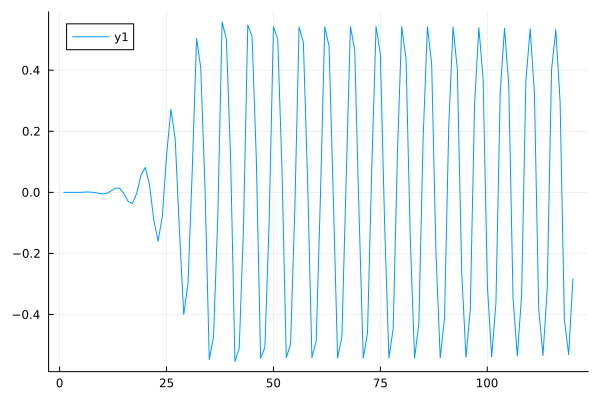

In [10]:
plot_strouhal(smac)

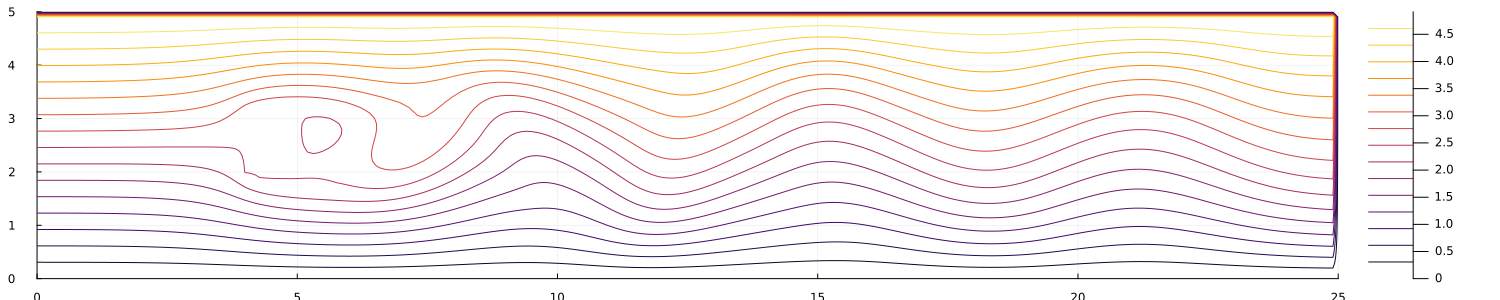

In [11]:
plot_streamline(smac)

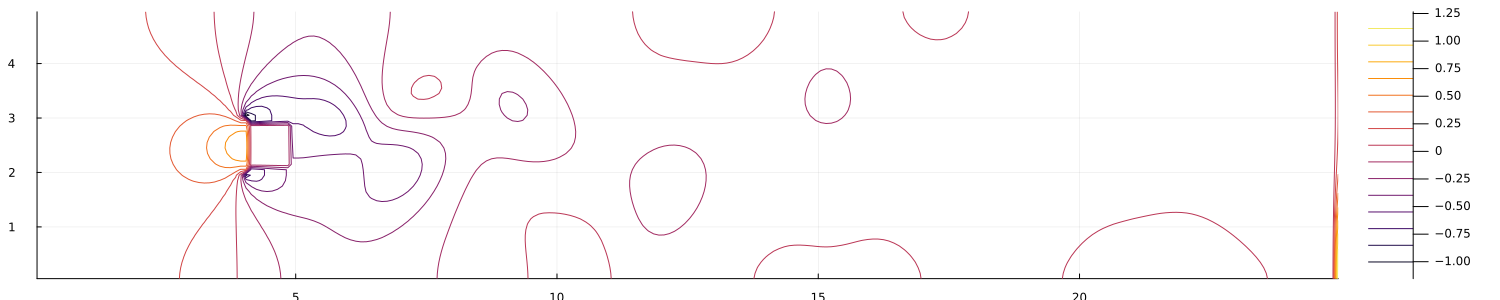

In [16]:
plot_pressure(smac)

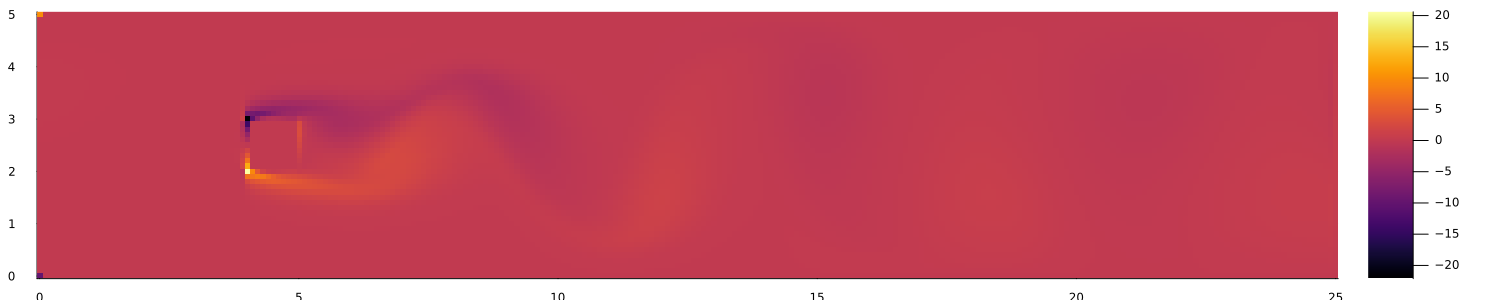

In [19]:
plot_vorticity(smac)